In [1]:
import pandas as pd
import os
from visualize_mhcsubgroup import plot_mhc_responders_vs_progressors
def addColumns(data):
    # Responders: CR/PR, Non responder: PD
    responderCrit = data['BR'].isin(['CR','PR'])
    progressorCrit = data['BR'].isin(['PD'])
    
    data["PD_Responders"] = "SD/MR"
    responders = data[responderCrit].index
    progressors = data[progressorCrit].index
    nonresponders = data[~responderCrit].index
    nonprogressors = data[~progressorCrit].index
    
    data.loc[responders,"PD_Responders"] = 'Responder'
    data.loc[progressors,"PD_Responders"] = 'Progressor'
    return data

******0******


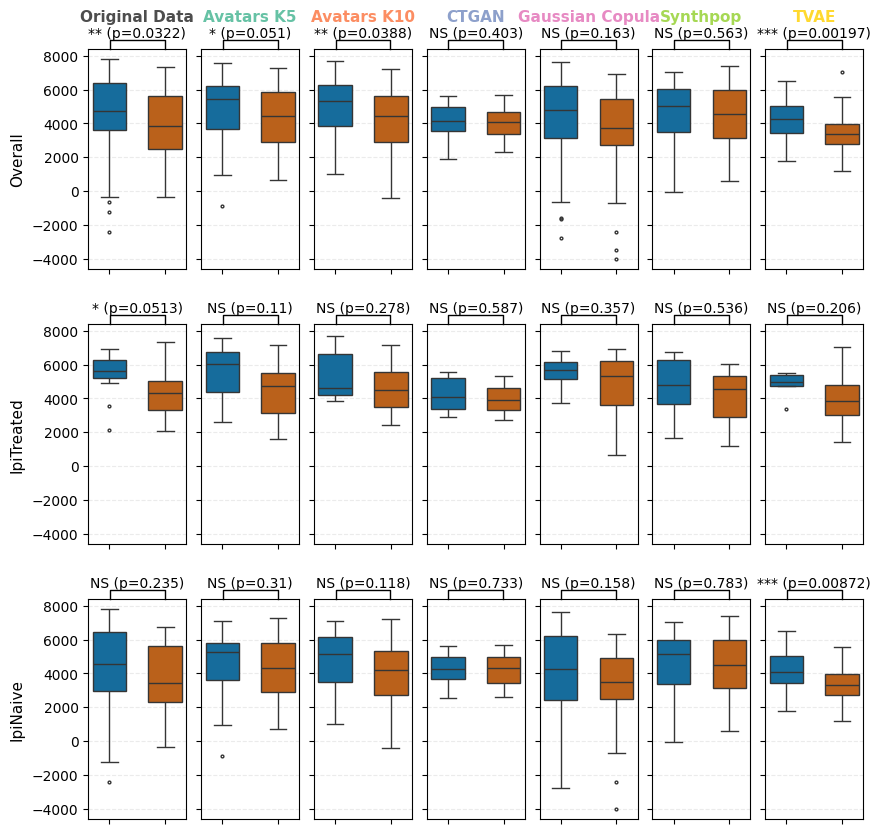

******1******


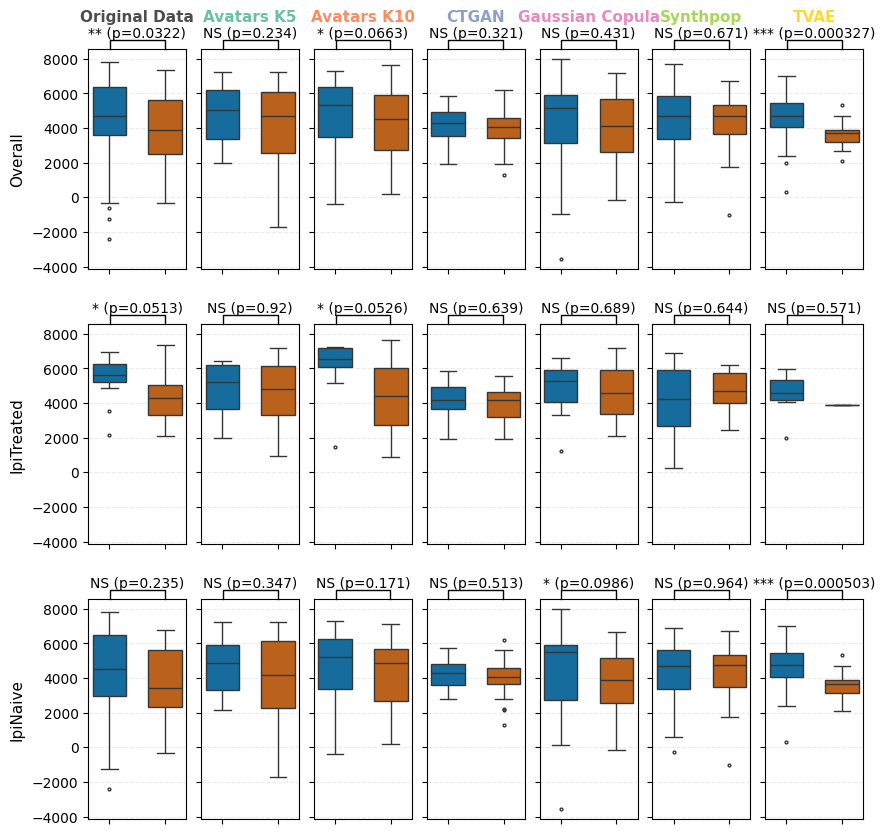

******2******


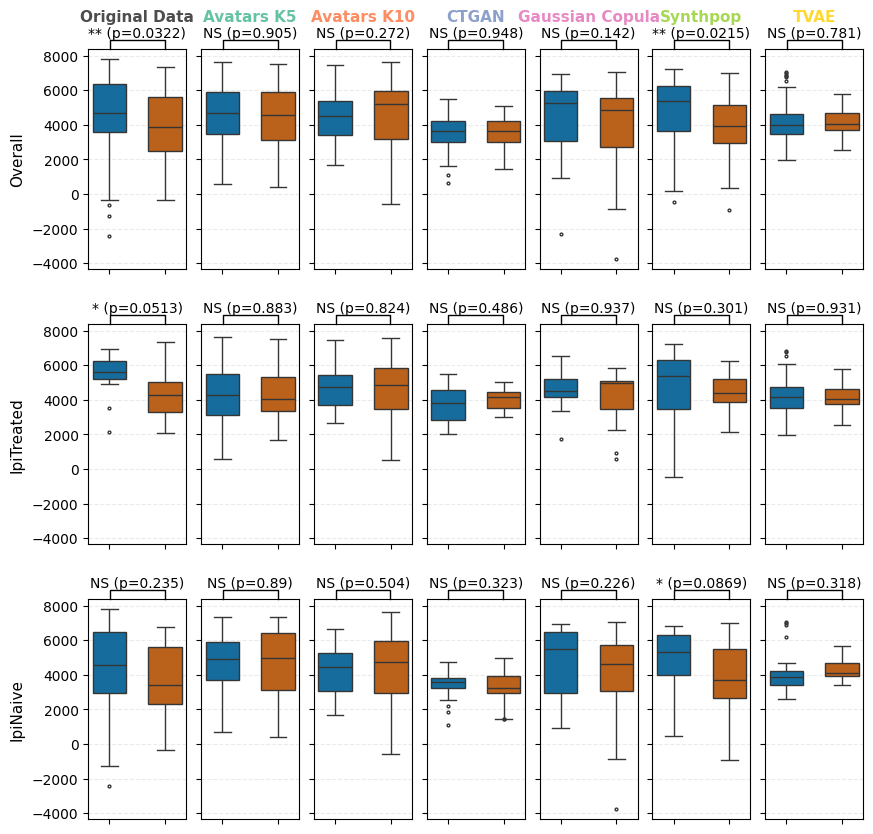

******3******


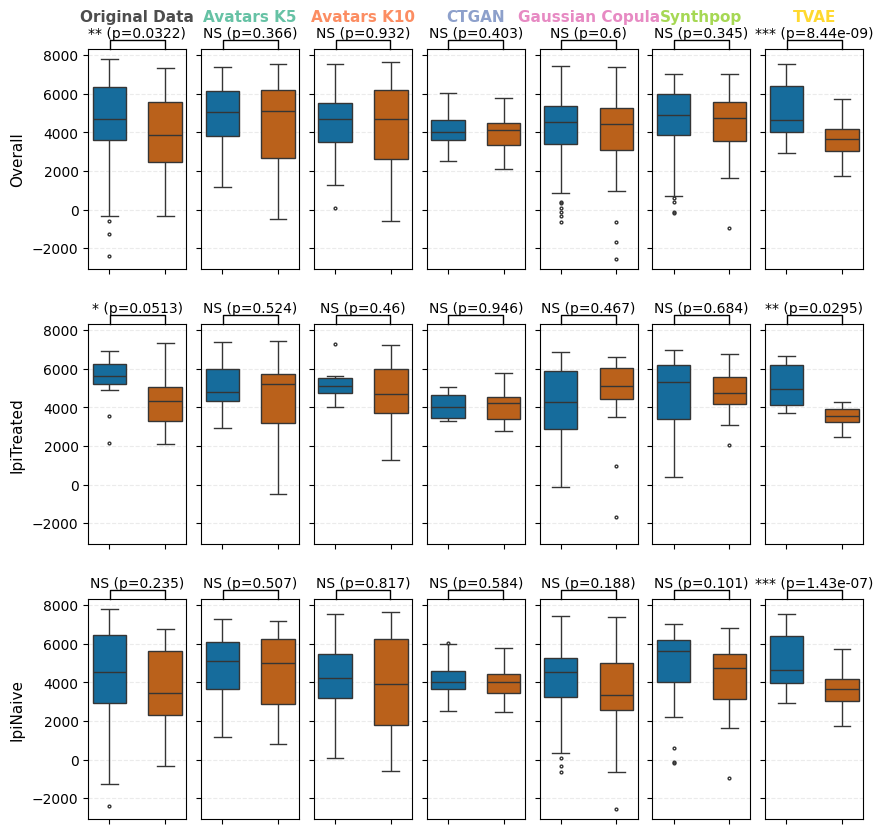

******42******


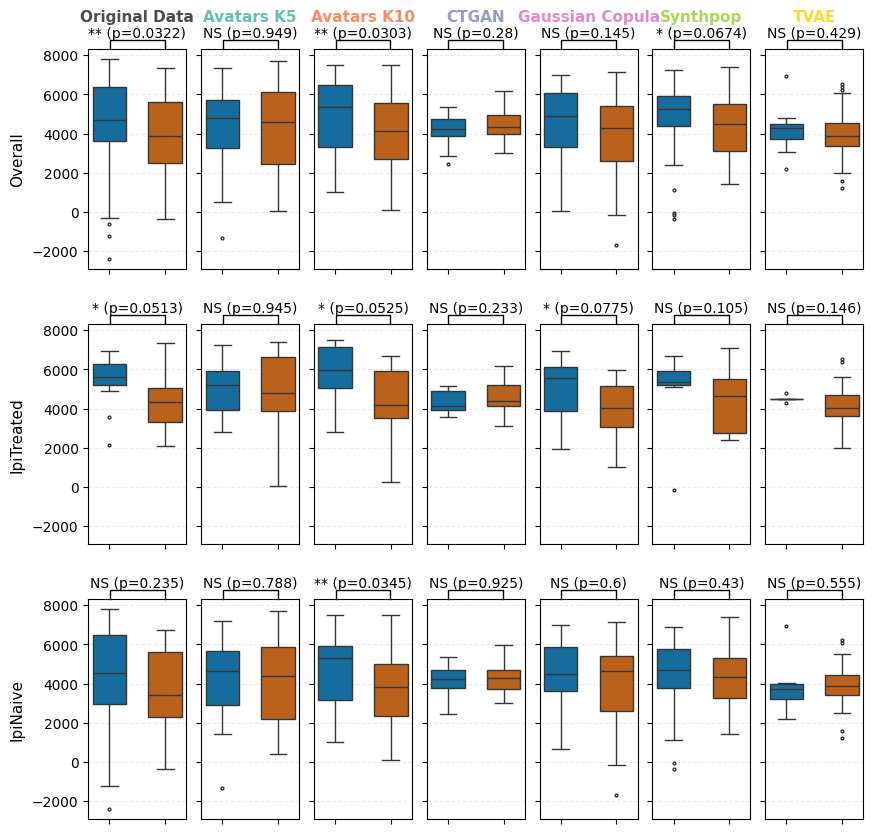

In [2]:
seeds = [0,1,2,3,42]
os.makedirs("MHCIISubgroup/", exist_ok = True)
for seed in seeds:
    print(f"******{seed}******")
    names = ['Original Data','Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
    datasets = ['original_data', f'avatarsk5_{seed}', f'avatarsk10_{seed}', f'ctgan_{seed}', f'gaussiancopula_{seed}', f'synthpop_{seed}', f'tvae_{seed}']
    
    dataset_dict = {}
    
    for i, dataset in enumerate(datasets):
        data = pd.read_csv(f'../Melanoma/Data/{dataset}.csv', index_col = 0)
        ssgsea = pd.read_csv(f'../Melanoma/NarrowUtility/ssGSEA/MHC/{dataset}.csv', index_col = 0)
    
        df_merged = pd.concat([data, ssgsea], axis = 1)
        dataset_dict[names[i]]=df_merged
        
    mhc_dict = {}
    for dataset, df_merge in dataset_dict.items():
        mhc_subgroups = {}
        BR_bin_df = addColumns(df_merge)
    
        #Overall
        responders = df_merge[df_merge['PD_Responders']=='Responder']['MHC-II'].values.tolist()
        progressor = df_merge[df_merge['PD_Responders']=='Progressor']['MHC-II'].values.tolist()
    
        #Ipi Treated
        ipi_treated_df = df_merge[df_merge['daysBiopsyAfterIpiStart']=='postIpi']
        responder_ipi = ipi_treated_df[ipi_treated_df['PD_Responders']=='Responder']['MHC-II'].values.tolist()
        progressor_ipi = ipi_treated_df[ipi_treated_df['PD_Responders']=='Progressor']['MHC-II'].values.tolist()
    
        #Ipi Naive
        ipi_naive_df =  df_merge[df_merge['daysBiopsyAfterIpiStart']=='noIpi']
        responder_naive = ipi_naive_df[ipi_naive_df['PD_Responders']=='Responder']['MHC-II'].values.tolist()
        progressor_naive = ipi_naive_df[ipi_naive_df['PD_Responders']=='Progressor']['MHC-II'].values.tolist()
    
        mhc_subgroups = {
            'Overall': {'Responder': responders, 'Progressor': progressor},
            'IpiTreated': {'Responder': responder_ipi, 'Progressor': progressor_ipi},
            'IpiNaive': {'Responder': responder_naive, 'Progressor': progressor_naive}
        }
    
        mhc_dict[dataset]=mhc_subgroups
    
    DATASET_COLORS = {
            "Original Data": "#4d4d4d",
            "Avatars K5": "#66c2a5",
            "Avatars K10": "#fc8d62",
            "CTGAN": "#8da0cb",
            "Gaussian Copula": "#e78ac3",
            "Synthpop": "#a6d854",
            "TVAE": "#ffd92f",
        }
    RESPONDER_COL = "#0072B2"
    NRESPONDER_COL = "#D55E00"
    fig = plot_mhc_responders_vs_progressors(
        mhc_dict=mhc_dict,
        datasets_order=["Original Data", "Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"],
        dataset_colors=DATASET_COLORS,
        group_palette={
            "Responder": RESPONDER_COL,
            "Progressor": NRESPONDER_COL,
        },
        figsize=(10, 10),
        show_points=True,
        points_style=None,  
        show_legend=False
    )
    
    fig.savefig(f"MHCIISubgroup/MHCII_Subgroups_{seed}.pdf", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(f"MHCIISubgroup/MHCII_Subgroups_{seed}.png", dpi=300, bbox_inches="tight", facecolor="white")

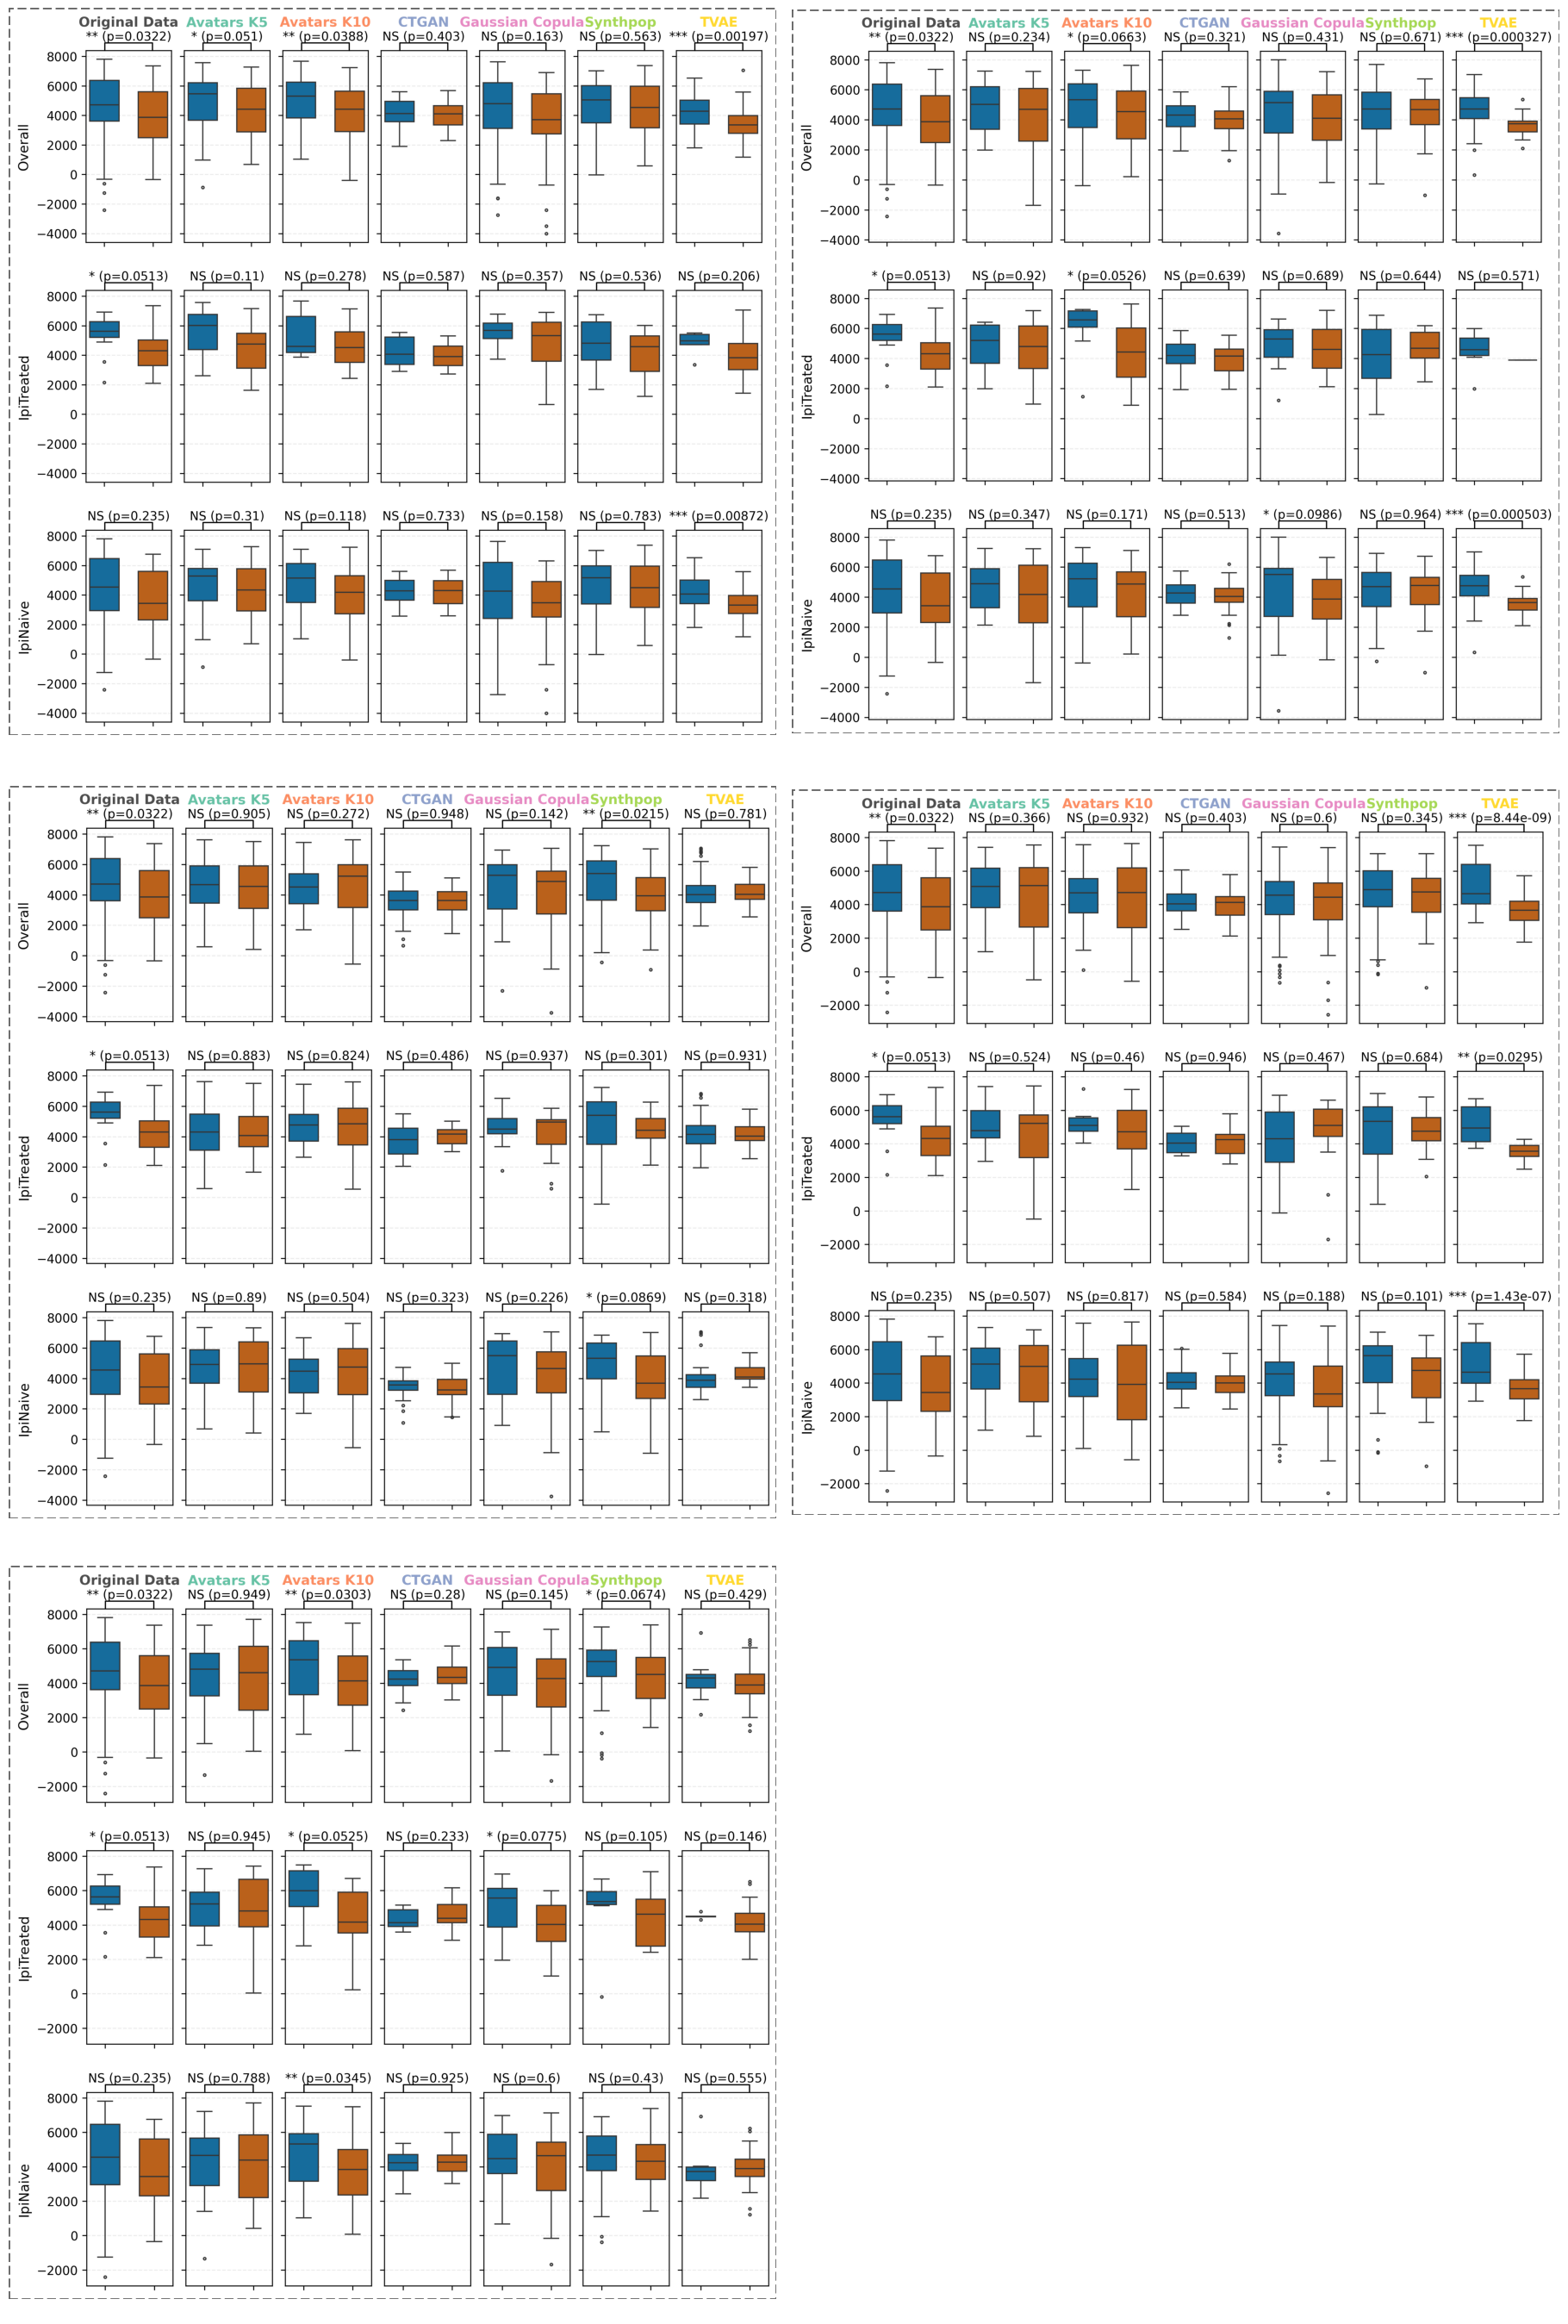

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches # Import thêm thư viện để vẽ hình khối
from matplotlib import gridspec

# Cấu hình
seeds = [0, 1, 2, 3, 42]
n_rows = 3
n_cols = 2

fig = plt.figure(figsize=(20, 30))

gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig,
    wspace=0.02, 
    hspace=0.02  
)

def show_img(ax, path):
    try:
        img = mpimg.imread(path)
        ax.imshow(img)
        
        # --- PHẦN THÊM VIỀN DASH ---
        # Vẽ một hình chữ nhật bao quanh toàn bộ khung của ax
        # transform=ax.transAxes giúp tọa độ (0,0) là góc dưới trái, (1,1) là góc trên phải của ô đó
        rect = patches.Rectangle(
            (0, 0), 1, 1, 
            linewidth=2, 
            edgecolor='#666666', # Màu xám đậm
            facecolor='none', 
            linestyle='--',      # Kiểu nét đứt (dash)
            transform=ax.transAxes
        )
        ax.add_patch(rect)
        # ---------------------------

    except FileNotFoundError:
        ax.text(0.5, 0.5, "Image Not Found", ha='center', va='center', fontsize=12)
    
    ax.axis("off")

for i, seed in enumerate(seeds):
    row = i // n_cols   
    col = i % n_cols    
    
    path = f"MHCIISubgroup/MHCII_Subgroups_{seed}.png"
    ax = fig.add_subplot(gs[row, col])
    
    # Bạn có thể thêm tiêu đề nhỏ để phân biệt replicate rõ hơn
    # ax.set_title(f"Replicate: Seed {seed}", fontsize=15, pad=10, fontweight='bold')
    
    show_img(ax, path)

if len(seeds) < n_rows * n_cols:
    for j in range(len(seeds), n_rows * n_cols):
        ax_empty = fig.add_subplot(gs[j // n_cols, j % n_cols])
        ax_empty.axis("off")

# Đừng dùng tight_layout() nếu viền bị cắt, thay vào đó căn chỉnh thủ công
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

fig.savefig("MHCIISubgroup/Combined_2x3.png", dpi=300, bbox_inches="tight")
plt.show()